# 01 - Market Data

Download, inspect, and clean historical price data for the selected asset universe (SPY, QQQ, AAPL, MSFT, NVDA). This notebook covers data acquisition (via `yfinance`) and basic data quality checks.


## Setup

The reusable download/cache logic lives in `src/data.py` so it can be reused by later notebooks instead of being copy-pasted.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Make src/ importable from within notebooks/
sys.path.insert(0, str(Path.cwd().parent / "src"))
import data


## Download price data

We use `auto_adjust=True` in `yfinance`, which means the Open/High/Low/Close values are already adjusted for stock splits and cash dividends. This matters because a raw (unadjusted) close price would show artificial price jumps around split/dividend dates that have nothing to do with actual investment return — using adjusted prices keeps our later return calculations correct.


In [2]:
prices = data.download_prices(start="2010-01-01")
data.save_prices(prices)
prices.head()


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2010-01-04,AAPL,6.383613,6.415617,6.352208,6.400961,493729600
1,2010-01-05,AAPL,6.418607,6.448217,6.378228,6.412026,601904800
2,2010-01-06,AAPL,6.412026,6.437449,6.303454,6.310034,552160000
3,2010-01-07,AAPL,6.333363,6.340841,6.252607,6.298368,477131200
4,2010-01-08,AAPL,6.289996,6.340843,6.252909,6.340244,447610800


## Inspect the data

Before doing any analysis, we check: what columns/types do we have, what date range does each ticker cover, and is anything missing?


In [3]:
prices.info()


<class 'pandas.DataFrame'>
RangeIndex: 20990 entries, 0 to 20989
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    20990 non-null  datetime64[s]
 1   Ticker  20990 non-null  str          
 2   Open    20990 non-null  float64      
 3   High    20990 non-null  float64      
 4   Low     20990 non-null  float64      
 5   Close   20990 non-null  float64      
 6   Volume  20990 non-null  int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 1.2 MB


In [4]:
# Date range and row count per ticker -- flags tickers with a
# shorter history (e.g. a stock that IPO'd after our start date)
prices.groupby("Ticker")["Date"].agg(["min", "max", "count"])


,min,max,count
Ticker,,,
AAPL,2010-01-04,2026-09-11,4198
MSFT,2010-01-04,2026-09-11,4198
NVDA,2010-01-04,2026-09-11,4198
QQQ,2010-01-04,2026-09-11,4198
SPY,2010-01-04,2026-09-11,4198


In [5]:
# Missing values per column -- should be all zeros for clean data
prices.isna().sum()


Price
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## Quick visual check

A fast sanity-check plot. We use a log scale because the tickers span very different price levels and growth rates (e.g. NVDA vs. SPY), which would otherwise be hard to compare on one chart.


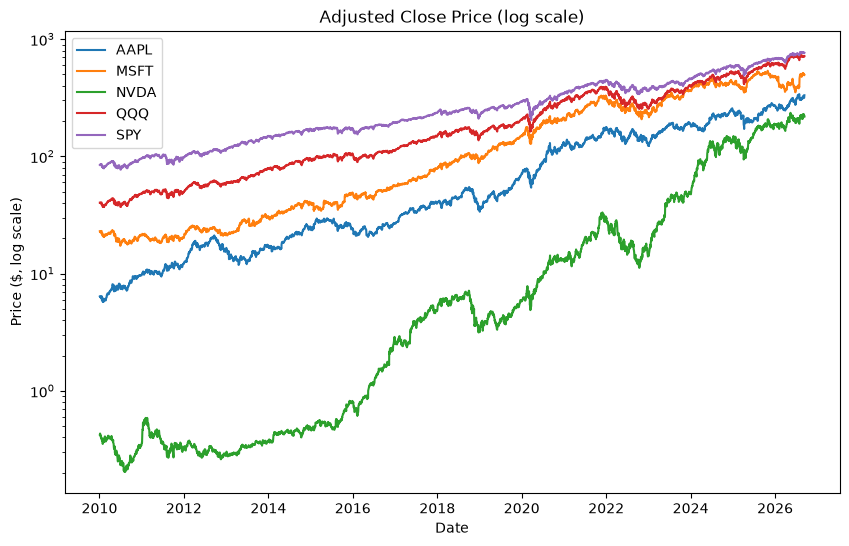

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for ticker, group in prices.groupby("Ticker"):
    ax.plot(group["Date"], group["Close"], label=ticker)

ax.set_yscale("log")
ax.set_title("Adjusted Close Price (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($, log scale)")
ax.legend()
plt.show()


## Notes / Next Step

Data looks clean: full history from 2010-01-04 for all five tickers, no missing values. Cached to `data/prices.csv` (git-ignored) so later notebooks can call `data.load_prices()` instead of re-downloading.

**Next:** `02_returns_and_risk.ipynb` -- calculate daily/cumulative returns and basic risk statistics from this price data.
